In [140]:
import warnings
import time
from __future__ import annotations
import datetime
from dataclasses import dataclass, field
from typing import Tuple, List, Optional

import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from category_encoders import CountEncoder
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8")
RANDOM_STATE: int = 42

#### 1. Download data from Don’tGetKicked competition.

kaggle competitions download -c DontGetKicked<br>
or direct download

##### 1.1 Read all the data

In [141]:
path: str = "data/DontGetKicked/{name}.csv"
train_df: pd.DataFrame = pd.read_csv(
    path.format(name="training"), parse_dates=["PurchDate"]
)
test_df: pd.DataFrame = pd.read_csv(
    path.format(name="test"), parse_dates=["PurchDate"]
)

##### 1.2 Drop columns with N/A > 50%

In [142]:
NA_threshold = 0.5
NA_percent = train_df.isnull().mean()
to_drop = NA_percent[NA_percent >= NA_threshold].index
train_df_wo_na = train_df.drop(columns=to_drop)

##### 1.3 Simple impute N/A for other columns and scale numeric

In [143]:
target = "IsBadBuy"
datetime_col = "PurchDate"
numeric = (
    train_df_wo_na.drop(target, axis=1)
    .select_dtypes(exclude=["object", "datetime"])
    .columns
)

categories = train_df_wo_na.select_dtypes(include="object").columns

numeric_pipeline = Pipeline(
    [
        ("num_imp", SimpleImputer(strategy="median")),
        ("st_scaler", StandardScaler()),
    ]
)

categories_pipeline = Pipeline(
    [
        ("cat_imp", SimpleImputer(strategy="constant", fill_value="unknown")),
    ]
)

col_tr = ColumnTransformer(
    transformers=[
        ("num_pipeline", numeric_pipeline, numeric),
        ("cat_pipeline", categories_pipeline, categories),
    ],
    remainder="drop",
)
train_df_tform_arr = col_tr.fit_transform(train_df_wo_na)

train_df_tform = pd.DataFrame(train_df_tform_arr)
train_df_tform.columns = numeric.to_list() + categories.to_list()
# add target and datetime col to final df
train_df_tform[datetime_col] = train_df_wo_na[datetime_col]
train_df_tform[target] = train_df_wo_na[target]

##### 1.4 Design the train/validation/test split. <br>Use the "PurchDate" field for the split, test must be later than validation, same for validation and train: train.PurchDate < valid.PurchDate < test.PurchDate. <br>Use the first 1/3 of dates for the train, the last 1/3 of dates for the test, and the middle 1/3 for the validation set. Don’t use the test dataset until the end!

In [144]:
# all funcs from ML3
def split_by_date(
    X: pd.DataFrame,
    date_split: datetime.datetime,
) -> Tuple[pd.DataFrame, pd.DataFrame]:

    info: pd.Series = X.dtypes
    date_in_df = [pd.api.types.is_datetime64_ns_dtype(x) for x in info.values]
    is_date_in_df = any(date_in_df)
    if not is_date_in_df:
        raise ValueError("No date col in df")

    # finds first entrance of datetype col
    date_col = info.index[date_in_df.index(True)]
    # sorts initial df to make proper split
    X = X.sort_values(by=date_col)
    X_train = X.loc[X[date_col] <= date_split]
    X_test = X.loc[X[date_col] > date_split]

    time_condition = X_train[date_col].max() < X_test[date_col].max()
    if not time_condition:
        raise ValueError("Split date cant provide proper split")

    return X_train, X_test


def validation_split_by_date(
    X: pd.DataFrame,
    validation_date: datetime.datetime,
    test_date: datetime.datetime,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:

    X_train, X_test = split_by_date(X, date_split=test_date)
    X_train, X_valid = split_by_date(X_train, date_split=validation_date)
    return X_train, X_valid, X_test


def check_split(df_list: List[pd.DataFrame], df_initial: pd.DataFrame) -> None:
    final_set: set = set(df_initial.index)
    for df in df_list:
        final_set -= set(df.index)
    print(final_set == set())
    [print(round(len(x) / len(df_initial), 2), end=" ") for x in df_list]

In [145]:
validation_date = datetime.datetime(year=2009, month=9, day=13)
test_date = datetime.datetime(year=2010, month=5, day=13)
X_train, X_valid, X_test = validation_split_by_date(
    X=train_df_tform, validation_date=validation_date, test_date=test_date
)
check_split(df_list=[X_train, X_valid, X_test], df_initial=train_df_tform)

True
0.33 0.34 0.33 

##### 1.5 Use LabelEncoder or OneHotEncoder from sklearn to preprocess categorical variables.<br> Be careful with data leakage (fit Encoder to training and apply to validation & test).<br> Consider another coding approach if you encounter new categorical values in validation & test (not seen in training): https://contrib.scikit-learn.org/category_encoders/count.html

In [146]:
cat_to_onehot_enc: list = []
cat_to_target_enc: list = []
for category in categories:
    # if there is many unique values we cant use OHE
    if X_train[category].value_counts().count() < 21:
        cat_to_onehot_enc.append(category)
    else:
        cat_to_target_enc.append(category)

In [147]:
# to avoid dummy variable trap use drop='first'
# when feature matrix becomes singular (determinant = 0)
one_hot_enc = OneHotEncoder(
    sparse_output=False,
    drop="first",
    feature_name_combiner="concat",
    handle_unknown="ignore",
)
cat_one_hot_enc = one_hot_enc.fit_transform(X_train[cat_to_onehot_enc])
cat_one_hot_enc = pd.DataFrame(
    cat_one_hot_enc, columns=one_hot_enc.get_feature_names_out()
)

count_enc = CountEncoder(normalize=True, min_group_size=15)
cat_count_enc = count_enc.fit_transform(X_train[cat_to_target_enc])

X_train_ = pd.concat(
    [
        X_train[numeric].reset_index(drop=True),
        cat_one_hot_enc.reset_index(drop=True),
        cat_count_enc.reset_index(drop=True),
        X_train[target].reset_index(drop=True),
    ],
    axis=1,
)

In [148]:
df_transformed = [pd.DataFrame(), pd.DataFrame()]

for num, df in enumerate([X_valid, X_test]):
    cat_one_hot_enc = one_hot_enc.transform(df[cat_to_onehot_enc])
    cat_one_hot_enc = pd.DataFrame(
        cat_one_hot_enc, columns=one_hot_enc.get_feature_names_out()
    )
    cat_count_enc = count_enc.transform(df[cat_to_target_enc])
    df_transformed[num] = pd.concat(
        [
            df[numeric].reset_index(drop=True),
            cat_one_hot_enc.reset_index(drop=True),
            cat_count_enc.reset_index(drop=True),
            df[target].reset_index(drop=True),
        ],
        axis=1,
    )

X_valid_, X_test_ = df_transformed

In [149]:
y_train_ = X_train_["IsBadBuy"]
X_train_ = X_train_.drop("IsBadBuy", axis=1).astype(np.float64)
y_valid_ = X_valid_["IsBadBuy"]
X_valid_ = X_valid_.drop("IsBadBuy", axis=1).astype(np.float64)
y_test_ = X_test_["IsBadBuy"]
X_test_ = X_test_.drop("IsBadBuy", axis=1).astype(np.float64)

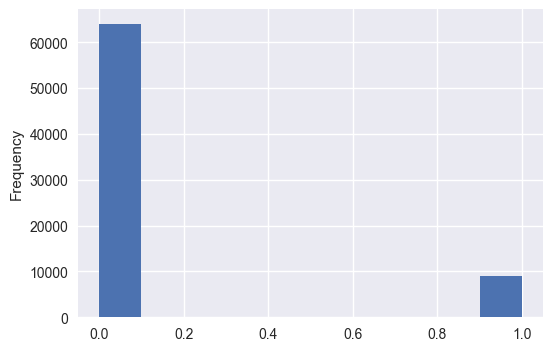

In [150]:
# change to pie
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))
train_df["IsBadBuy"].plot.hist(ax=ax)
fig.show()

Target classes are imbalanced

In [151]:
def gini_score_sk(y_true, y_score):
    """using 2*ROC AUC - 1 approach"""
    return round(2 * roc_auc_score(y_true=y_true, y_score=y_score) - 1, 4)

#### 2. Create a Python class, MLP with 1 hidden layer and sigmoid activation function at the end of the network.<br>It should support fit, predict_proba and predict methods. <br>Also, the number of neurons in the hidden layer and the activation function must be parameters of your class

Here is the blueprint:

```python
model = MLP(n_hidden=100, activation=np.arctan)
model.fit(Xtrain, ytrain)
model.predict_proba(Xvalid)
```

- Initialize the network with small random numbers.
- Use Log Loss (Binary Cross Entropy) as the loss function.
- Implement a forward pass; you can use a fixed batch size like 32, forward pass maps arrays of shape <br>(batch_size, number_of_features) to arrays of shape (batch_size, 2) where 2 means dimensions of [probability_of_0, probability_of_1] output space.
- Write down the gradients of the loss function with respect to the parameters of the net. Use [4](https://en.wikipedia.org/wiki/Backpropagation), [9](http://d2l.ai/) as a guide for deriving gradients.
- Use gradients to perform Backprop. Implement Backprop.
- Implement SGD algorithm to tune model parameters.
- Design a basic train-validation loop: iterate over the training dataset, batch by batch, update the parameters of the network, and check the quality of the model using the validation set.
- Write code to update network weights using SGD or Adam.

In [152]:
@dataclass
class MLP:
    """ 
    Multilayer Perceptron (MLP)
    """
    pass

#### 3. With your MLP module and careful network engineering, you must obtain at least a 0.15 Gini score on the validation dataset.<br> You can train for more than 1 epoch, use different activation functions, and different optimizers (like SGD or Adam).

#### 4. Use sklearn's MLPClassifier and check its performance on the validation dataset. Is it better than your module? If so, why?

In [153]:
out: pd.DataFrame = pd.DataFrame(
    {"model": [], "Gini": [], "Fit_time": [], "Predict_time": []}
)


# model = MLPClassifier(
#     hidden_layer_sizes=(60, ),
#     max_iter=20,
#     alpha=1e-4,
#     solver="adam",
#     random_state=42,
#     learning_rate_init=0.1,
#     activation='relu',
# )

model = MLPClassifier(
    activation='relu',
    solver="sgd",
    random_state=RANDOM_STATE,
)

start_time = time.time()
model.fit(X=X_train_, y=y_train_)
fit_time = round(time.time() - start_time, 4)
start_time = time.time()
y_pred = model.predict_proba(X=X_valid_)[:, 1]
predict_time = round(time.time() - start_time, 4)
out.loc[len(out)] = {
    "model": model.__class__.__name__,
    "Gini": gini_score_sk(y_true=y_valid_.values, y_score=y_pred),
    "Fit_time": fit_time,
    "Predict_time": predict_time,
}

out.reset_index(drop=True)

,model,Gini,Fit_time,Predict_time
0,MLPClassifier,0.4516,11.9319,0.02


#### 5. Implement and try different activation functions: sigmoid, ReLU, cosine.<br>Remember that you have to derive gradients for each different activation function.<br>Which activation function gives the best performance on the validation dataset?

#### 6. Design an MLP module with 1 hidden layer using any high level deep learning framework: Pytorch, Keras, or Tensorflow. <br>Check its performance on the validation dataset. Is it better than your module? If so, why?

In [154]:
# torch (Pytorch)
torch_model = 0

In [155]:
# Keras
keras_model = 0

In [156]:
# Tensorflow
tf_model = 0

#### 7. Take the best model and estimate its performance on the test dataset:<br> check the Gini scores on all three datasets for your best model: training Gini, valid Gini, test Gini.<br> Do you see a drop in performance when comparing the valid quality to the test quality? Is your model overfitting or not? Explain

In [157]:
# X is the best
final_out: pd.DataFrame = pd.DataFrame({"LogReg_l1": [], "roc_auc": [], "Gini": []})

for x, y, name in (
    (X_train_, y_train_, "train"),
    (X_valid_, y_valid_, "valid"),
    (X_test_, y_test_, "test"),
):
    y_pred = model.predict_proba(X=x)[:, 1]

    final_out.loc[len(final_out)] = {
        "LogReg_l1": name,
        "roc_auc": roc_auc_score(y_true=y, y_score=y_pred),
        "Gini": gini_score_sk(y_true=y, y_score=y_pred),
    }

final_out

,LogReg_l1,roc_auc,Gini
0,train,0.762339,0.5247
1,valid,0.725809,0.4516
2,test,0.737560,0.4751


Do you see a drop in performance when comparing the valid quality to the test quality?<br>
Yes, we see 13% drop in perfomance train to valid, but 4% improvement in valid to test
<br> Is your model overfitted or not? Explain. Yes, model shows mild overfitting.

One of the possible causes is unbalanced distribution of the target variable between samples. <br>

Train:&nbsp;&nbsp;[88.5% class_0, 11.5% class_1]<br>
Valid:&nbsp;&nbsp;[87.0% class_0, 13.0% class_1]<br>
Test:&nbsp;&nbsp;&nbsp;[87.6% class_0, 12.4% class_1]<br>

<br>(Big drop in perfomance = overfitting)

#### Bonus part.
#### B1. Implement the Adam algorithm to tune the parameters of the model.


#### * Sources
- 